In [1]:
import pandas as pd
import glob
import os
import warnings

warnings.filterwarnings("ignore")

In [2]:


# Define folder path
folder_path = "wishlists/adds.xlsx"


# Read all files into DataFrames and add filename column
adds = pd.read_excel(folder_path, skiprows=2)

adds.rename({"Selected Measure":"additions"}, axis=1, inplace=True)

In [3]:
adds.query("product=='Wanderstop'")

,Day,product,additions,Blank Measure
43,2018-01-01,Wanderstop,0,NaN
91,2018-01-02,Wanderstop,0,NaN
139,2018-01-03,Wanderstop,0,NaN
187,2018-01-04,Wanderstop,0,NaN
235,2018-01-05,Wanderstop,0,NaN
...,...,...,...,...
136583,2025-06-12,Wanderstop,558,NaN
136639,2025-06-13,Wanderstop,449,NaN
136695,2025-06-14,Wanderstop,1285,NaN
136751,2025-06-15,Wanderstop,1165,NaN


In [4]:
folder_path = "wishlists/activations.xlsx"


activations  = pd.read_excel(folder_path, skiprows=2)

activations.rename({"Selected Measure":"activations"}, axis=1, inplace=True)

In [5]:
adds = adds.drop("Blank Measure", axis=1)
activations = activations.drop("Blank Measure", axis=1)

In [6]:
adds.drop_duplicates("product").to_clipboard()

In [7]:
folder_path = "wishlists/Annapurna Interactive Historical Revenues - releases_dates.csv"


dates  = pd.read_csv(folder_path)
dates = dates.dropna(subset='pc_release_date')

In [8]:
dates

,product,pc_release_date
0,Faraway,2025-12-31
1,Mixtape,2025-12-31
2,The Lost Wild,2026-11-01
3,Wheel World,2025-07-23
4,BattleSage,2025-06-30
5,to a T,2025-05-28
6,Skin Deep,2025-04-30
7,Lushfoil Photography Sim,2025-04-15
8,Wanderstop,2025-03-11
9,Morsels,2025-02-28


In [9]:
df = pd.merge(adds, activations, on=['product', 'Day'], how='left')

In [10]:
dates['product'].unique()

array(['Faraway', 'Mixtape', 'The Lost Wild', 'Wheel World', 'BattleSage',
       'to a T', 'Skin Deep', 'Lushfoil Photography Sim', 'Wanderstop',
       'Morsels', 'Flock', 'Lorelei and the Laser Eyes', 'Open Roads',
       'Thirsty Suitors', 'Cocoon', 'Storyteller', 'Solar Ash',
       'Hindsight', 'Hohokum', 'Stray', 'Neon White', 'A Memoir Blue',
       'The Pathless', 'The Artful Escape', 'Twelve Minutes', 'Last Stop',
       'Mundaun', 'Maquette', 'Wattam', 'Due Process', 'I Am Dead',
       'The Unfinished Swan', 'Outer Wilds', 'Journey', 'If Found...',
       'Florence', 'Kentucky Route Zero: TV Edition',
       'Sayonara Wild Hearts', 'Ashen', 'Telling Lies', 'Flower',
       'Donut County', 'Gorogoa', 'What Remains of Edith Finch',
       'LEGO Voyagers', 'Snap & Grab'], dtype=object)

In [11]:
dates['pc_release_date'] = pd.to_datetime(dates['pc_release_date'])
df['release_date'] = pd.to_datetime(df['Day'])


In [12]:
release_date_dict = dates.groupby('product')['pc_release_date'].min().to_dict()

In [13]:
release_date_dict

{'A Memoir Blue': Timestamp('2022-03-24 00:00:00'),
 'Ashen': Timestamp('2019-12-09 00:00:00'),
 'BattleSage': Timestamp('2025-06-30 00:00:00'),
 'Cocoon': Timestamp('2023-09-29 00:00:00'),
 'Donut County': Timestamp('2018-08-28 00:00:00'),
 'Due Process': Timestamp('2020-11-03 00:00:00'),
 'Faraway': Timestamp('2025-12-31 00:00:00'),
 'Flock': Timestamp('2024-07-16 00:00:00'),
 'Florence': Timestamp('2020-02-13 00:00:00'),
 'Flower': Timestamp('2019-02-14 00:00:00'),
 'Gorogoa': Timestamp('2017-12-14 00:00:00'),
 'Hindsight': Timestamp('2022-08-04 00:00:00'),
 'Hohokum': Timestamp('2022-07-28 00:00:00'),
 'I Am Dead': Timestamp('2020-10-08 00:00:00'),
 'If Found...': Timestamp('2020-05-19 00:00:00'),
 'Journey': Timestamp('2020-06-11 00:00:00'),
 'Kentucky Route Zero: TV Edition': Timestamp('2020-01-28 00:00:00'),
 'LEGO Voyagers': Timestamp('2025-09-01 00:00:00'),
 'Last Stop': Timestamp('2021-07-22 00:00:00'),
 'Lorelei and the Laser Eyes': Timestamp('2024-05-16 00:00:00'),
 'Lushfo

In [14]:
df['release_date'] = df['product'].map(release_date_dict)


In [15]:
df["DBR"] = (df["Day"] - df["release_date"]).dt.days


In [16]:
df["Weeks_from_Release"] = (df["DBR"] // 7) + 1  # Week 1 starts at 0-7 days


In [17]:
df['cumulative_additions'] = df.groupby('product')['additions'].cumsum()
df['cumulative_activations'] = df.groupby('product')['activations'].cumsum()


In [18]:
df['cumulative_act_rate'] = df['cumulative_activations'] / df['cumulative_additions']
df['act_rate'] = df['activations'] / df['additions']

In [19]:
df.drop_duplicates(subset='product', keep='last').sort_values(by='cumulative_additions', ascending=False)

,Day,product,additions,activations,release_date,DBR,Weeks_from_Release,cumulative_additions,cumulative_activations,cumulative_act_rate,act_rate
136797,2025-06-16,Stray,1190,85,2022-07-19,1063.0,152.0,10990139,2764944,0.251584,0.071429
136789,2025-06-16,Outer Wilds,514,39,2020-06-18,1824.0,261.0,4981369,1478203,0.296746,0.075875
136809,2025-06-16,What Remains of Edith Finch,200,13,2017-04-25,2974.0,425.0,2139912,824461,0.385278,0.065000
136775,2025-06-16,Journey,0,0,2020-06-11,1831.0,262.0,1847305,710975,0.384871,NaN
136786,2025-06-16,Neon White,34,3,2022-06-16,1096.0,157.0,1333943,278033,0.208429,0.088235
136805,2025-06-16,Twelve Minutes,43,2,2021-08-19,1397.0,200.0,1207666,175434,0.145267,0.046512
136796,2025-06-16,Storyteller,0,0,2023-03-23,816.0,117.0,1097950,191570,0.174480,NaN
136762,2025-06-16,Cocoon,53,2,2023-09-29,626.0,90.0,1040712,143723,0.138101,0.037736
136757,2025-06-16,Ashen,30,0,2019-12-09,2016.0,289.0,894666,113149,0.126471,0.000000
136763,2025-06-16,Donut County,27,2,2018-08-28,2484.0,355.0,864825,226963,0.262438,0.074074


In [20]:

#df['release_date'] = df.groupby('product')['release_date'].transform('min')
#df_combined["DAR"] = df_combined["DAR"].clip(lower=0)


#df = df.query("0 <= Weeks_from_Release <=12")

#df = df.query("'1/1/2015' <= release_date <='1/1/2026'")

#df = df.groupby(["product",'Date', "Weeks_from_Release"], as_index=False)["units"].max()
df = df.groupby(["product", "Weeks_from_Release"], as_index=False)[["additions", 'cumulative_additions','cumulative_activations','act_rate', 'cumulative_act_rate']].max()

In [21]:
df['product'].unique()

array(['A Memoir Blue', 'Ashen', 'BattleSage', 'Cocoon', 'Donut County',
       'Due Process', 'Faraway', 'Flock', 'Florence', 'Flower', 'Gorogoa',
       'Hindsight', 'Hohokum', 'I Am Dead', 'If Found...', 'Journey',
       'Kentucky Route Zero: TV Edition', 'LEGO Voyagers', 'Last Stop',
       'Lorelei and the Laser Eyes', 'Lushfoil Photography Sim',
       'Maquette', 'Mixtape', 'Morsels', 'Mundaun', 'Neon White',
       'Open Roads', 'Outer Wilds', 'Sayonara Wild Hearts', 'Skin Deep',
       'Snap & Grab', 'Solar Ash', 'Storyteller', 'Stray', 'Telling Lies',
       'The Artful Escape', 'The Lost Wild', 'The Pathless',
       'The Unfinished Swan', 'Thirsty Suitors', 'Twelve Minutes',
       'Wanderstop', 'Wattam', 'What Remains of Edith Finch',
       'Wheel World', 'to a T'], dtype=object)

In [22]:
title = 'to a T'

In [23]:
df.query("product==@title")

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
16308,to a T,-386.0,0,0,0,NaN,NaN
16309,to a T,-385.0,0,0,0,NaN,NaN
16310,to a T,-384.0,0,0,0,NaN,NaN
16311,to a T,-383.0,0,0,0,NaN,NaN
16312,to a T,-382.0,0,0,0,NaN,NaN
...,...,...,...,...,...,...,...
16693,to a T,-1.0,1456,33054,0,0.000000,0.000000
16694,to a T,0.0,758,36441,0,0.000000,0.000000
16695,to a T,1.0,4788,50565,2808,0.297410,0.055532
16696,to a T,2.0,811,54570,3325,0.187328,0.060931


In [24]:
current_cume = df.query("product==@title")['cumulative_additions'].values[-1]
current_week = df.query("product==@title")['Weeks_from_Release'].values[-1]

In [25]:
current_week

3.0

In [26]:
title_df = df.query("product==@title")

In [27]:
title_df

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
16308,to a T,-386.0,0,0,0,NaN,NaN
16309,to a T,-385.0,0,0,0,NaN,NaN
16310,to a T,-384.0,0,0,0,NaN,NaN
16311,to a T,-383.0,0,0,0,NaN,NaN
16312,to a T,-382.0,0,0,0,NaN,NaN
...,...,...,...,...,...,...,...
16693,to a T,-1.0,1456,33054,0,0.000000,0.000000
16694,to a T,0.0,758,36441,0,0.000000,0.000000
16695,to a T,1.0,4788,50565,2808,0.297410,0.055532
16696,to a T,2.0,811,54570,3325,0.187328,0.060931


In [28]:
ranked_df = df.query("Weeks_from_Release ==-1").sort_values(by='cumulative_additions', ascending=False)

In [29]:
range = 0.50

high_end = current_cume * (1 + range)
low_end = current_cume * (1 - range)

In [30]:
low_end

28110.0

In [31]:
df_filtered = ranked_df[~ranked_df['product'].str.contains('Soundtrack', case=False, na=False)]
df_filtered.query("additions>0")

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
11864,Stray,-1.0,52206,2458525,141327,0.204286,0.057484
9802,Outer Wilds,-1.0,1084,407893,3,0.000000,0.000007
489,Ashen,-1.0,350,234635,9,0.000000,0.000039
15122,Wanderstop,-1.0,9542,225047,0,0.000000,0.000000
14546,Twelve Minutes,-1.0,1309,187333,10,0.002817,0.000053
11509,Storyteller,-1.0,740,165019,0,0.000000,0.000000
7324,Lushfoil Photography Sim,-1.0,1180,140498,2,0.000000,0.000015
11104,Solar Ash,-1.0,591,126256,11483,0.011869,0.092544
5614,Journey,-1.0,2447,105446,0,0.000000,0.000000
9609,Open Roads,-1.0,297,101608,1,0.000000,0.000010


In [32]:
df_filtered.query("@low_end < cumulative_additions <@high_end")

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
9126,Neon White,-1.0,415,83367,1556,0.244131,0.018664
1468,Cocoon,-1.0,748,81569,1439,0.078995,0.017642
10836,Skin Deep,-1.0,89,76952,34,0.094118,0.000442
2097,Due Process,-1.0,113,54465,9278,0.615385,0.170348
2708,Flock,-1.0,289,53511,0,0.000000,0.000000
14271,Thirsty Suitors,-1.0,102,44597,60,0.000000,0.001359
13389,The Pathless,-1.0,356,43032,3166,0.021429,0.076080
15291,Wattam,-1.0,159,38623,4,0.017544,0.000104
6886,Lorelei and the Laser Eyes,-1.0,373,37370,0,0.000000,0.000000
8487,Morsels,-1.0,62,34638,3,0.000000,0.000087


In [33]:
df_filtered['pct_rank'] = df_filtered['cumulative_additions'].rank(pct=True)

In [34]:
df_filtered

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate,pct_rank
11864,Stray,-1.0,52206,2458525,141327,0.204286,0.057484,1.000000
9802,Outer Wilds,-1.0,1084,407893,3,0.000000,0.000007,0.973684
489,Ashen,-1.0,350,234635,9,0.000000,0.000039,0.947368
15122,Wanderstop,-1.0,9542,225047,0,0.000000,0.000000,0.921053
14546,Twelve Minutes,-1.0,1309,187333,10,0.002817,0.000053,0.894737
11509,Storyteller,-1.0,740,165019,0,0.000000,0.000000,0.868421
7324,Lushfoil Photography Sim,-1.0,1180,140498,2,0.000000,0.000015,0.842105
11104,Solar Ash,-1.0,591,126256,11483,0.011869,0.092544,0.815789
5614,Journey,-1.0,2447,105446,0,0.000000,0.000000,0.789474
9609,Open Roads,-1.0,297,101608,1,0.000000,0.000010,0.763158


In [35]:
df_filtered.query("product==@title")

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate,pct_rank
16693,to a T,-1.0,1456,33054,0,0.0,0.0,0.473684


In [36]:
stop

NameError: name 'stop' is not defined

## Wishlist Activation Rates over time.

In [37]:
df = df[~df['product'].str.contains('Soundtrack', case=False, na=False)]


In [38]:
act_rate_df = df.query("Weeks_from_Release >=1")

In [39]:
#act_rate_df["DAR"] = act_rate_df.groupby("product")["DAR"].transform(lambda x: x.clip(lower=0))


In [40]:
act_rate_df

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
221,A Memoir Blue,1.0,2305,23545,925,0.230727,0.039286
222,A Memoir Blue,2.0,679,27662,1059,0.056836,0.039953
223,A Memoir Blue,3.0,447,30157,1151,0.049751,0.038582
224,A Memoir Blue,4.0,280,31905,1238,0.072797,0.038851
225,A Memoir Blue,5.0,198,33150,1320,0.115942,0.039819
...,...,...,...,...,...,...,...
15916,What Remains of Edith Finch,424.0,1966,2131092,823726,0.525974,0.386628
15917,What Remains of Edith Finch,425.0,1617,2139912,824461,0.161357,0.386349
16695,to a T,1.0,4788,50565,2808,0.297410,0.055532
16696,to a T,2.0,811,54570,3325,0.187328,0.060931


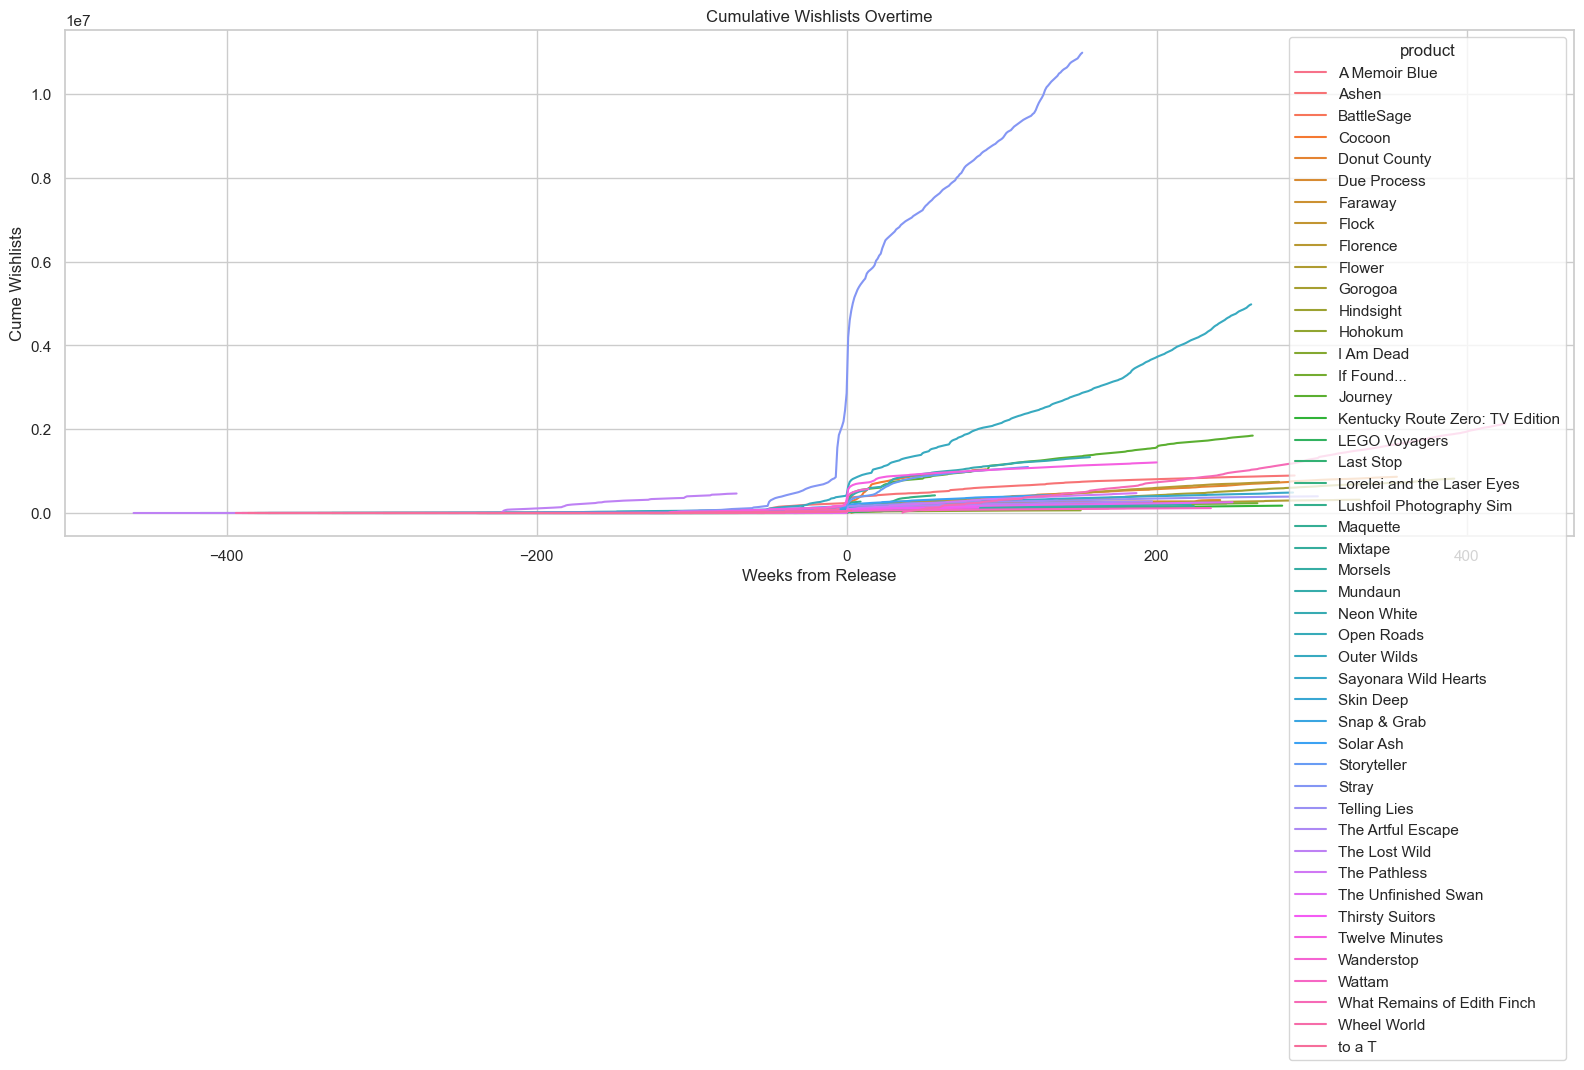

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style for aesthetics
sns.set_theme(style="whitegrid")

# Plot the data
plt.figure(figsize=(16, 9))
sns.lineplot(data=df, x="Weeks_from_Release", y="cumulative_additions", hue='product')

# Adding titles and labels
plt.title("Cumulative Wishlists Overtime")
plt.xlabel("Weeks from Release")
plt.ylabel("Cume Wishlists")

# Show the plot
plt.tight_layout()
plt.show()

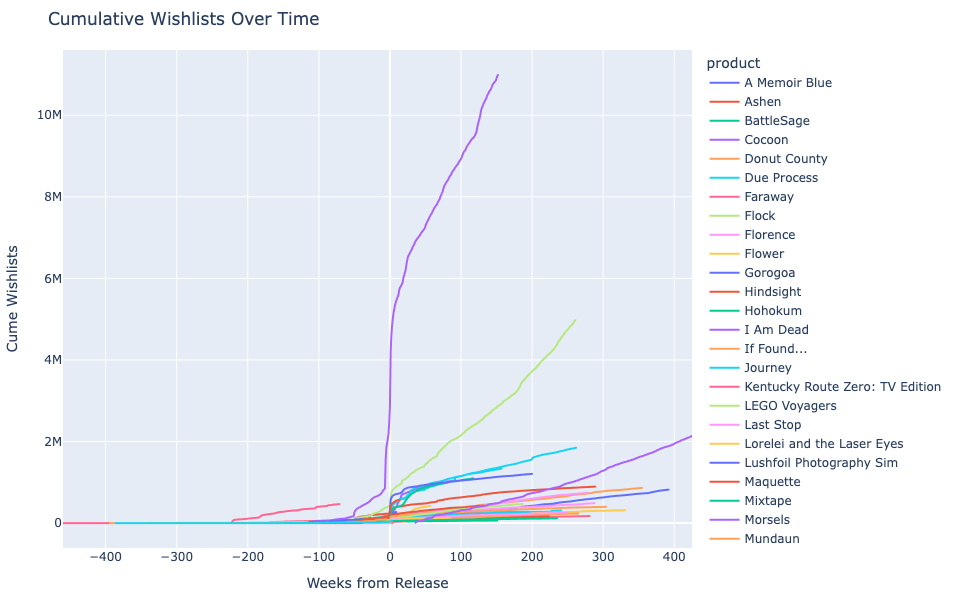

In [42]:
import plotly.express as px

# Create the interactive line plot
fig = px.line(df, 
              x="Weeks_from_Release", 
              y="cumulative_additions", 
              color='product',
              title="Cumulative Wishlists Over Time",
              labels={
                  "Weeks_from_Release": "Weeks from Release",
                  "cumulative_additions": "Cume Wishlists"
              })

# Update the layout for better aesthetics
fig.update_layout(
    autosize=True,
    height=600,
    margin=dict(l=20, r=20, t=50, b=20),
    hovermode='closest'
)

# Save as HTML
fig.write_html("docs/cumulative_wishlists_overtime.html")

# Show the interactive plot
fig.show()

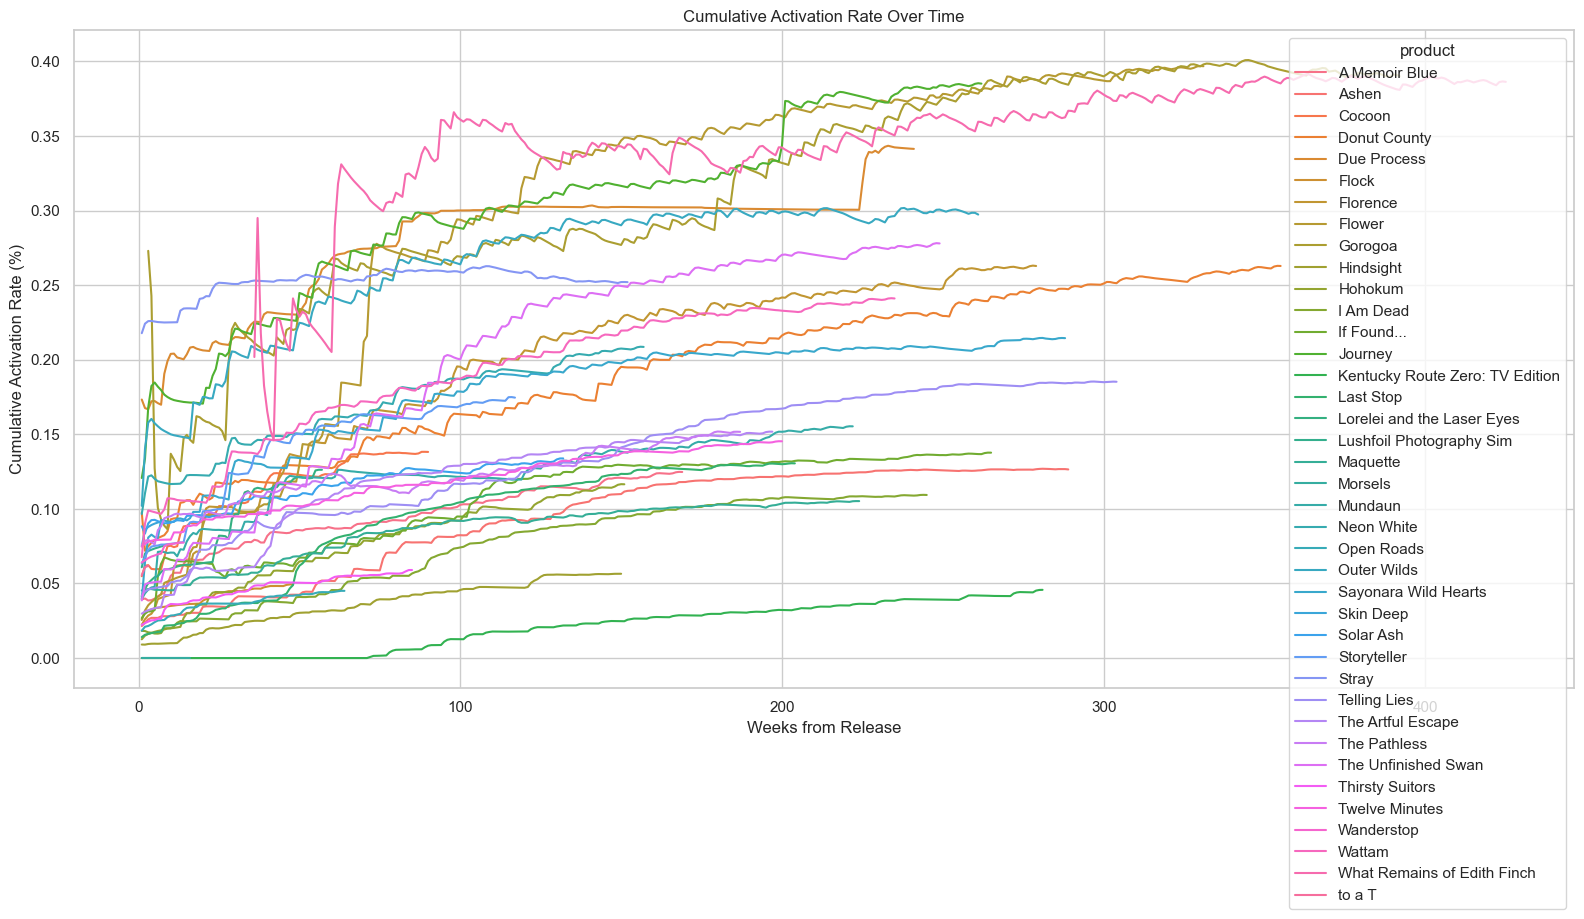

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style for aesthetics
sns.set_theme(style="whitegrid")

# Plot the data
plt.figure(figsize=(16, 9))
sns.lineplot(data=act_rate_df, x="Weeks_from_Release", y="cumulative_act_rate", hue='product')


# Adding titles and labels
plt.title("Cumulative Activation Rate Over Time")
plt.xlabel("Weeks from Release")
plt.ylabel("Cumulative Activation Rate (%)")

# Show the plot
plt.tight_layout()
plt.show()

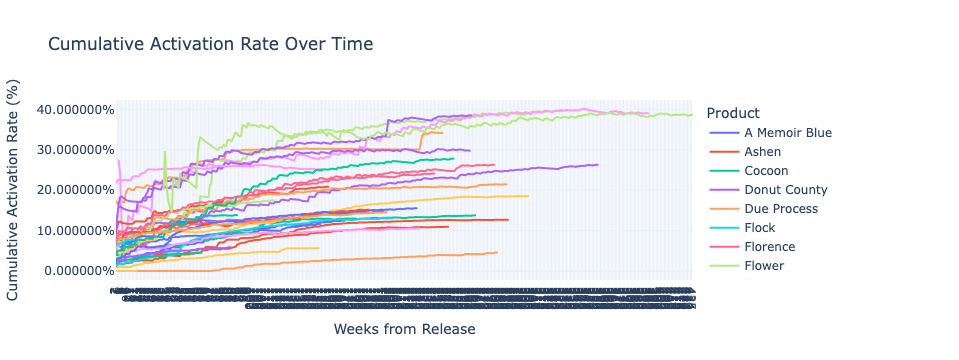

In [44]:
import plotly.express as px

# Create the Plotly line plot
fig = px.line(
    act_rate_df,
    x="Weeks_from_Release",
    y="cumulative_act_rate",
    color='product',
    title="Cumulative Activation Rate Over Time",
    labels={
        "Weeks_from_Release": "Weeks from Release",
        "cumulative_act_rate": "Cumulative Activation Rate (%)"
    },
    template='plotly_white'
)

# Improve layout for readability
fig.update_layout(
    legend_title_text='Product',
    xaxis=dict(tickmode='linear'),
    yaxis_tickformat='%'
)

# Display the plot
fig.show()

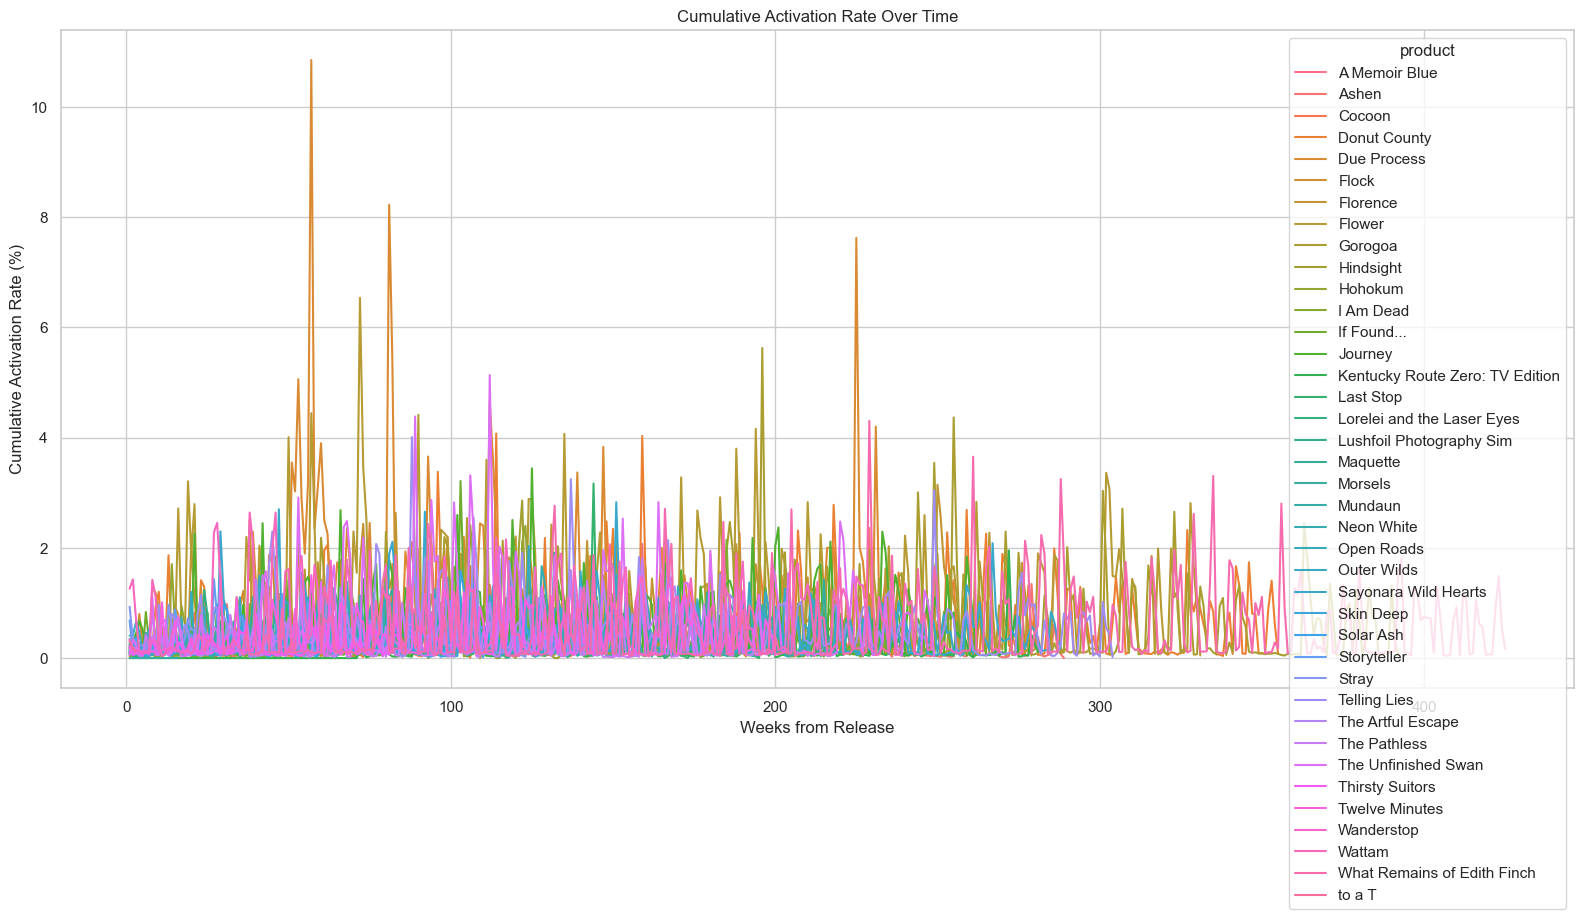

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style for aesthetics
sns.set_theme(style="whitegrid")

# Plot the data
plt.figure(figsize=(16, 9))
sns.lineplot(data=act_rate_df, x="Weeks_from_Release", y="act_rate", hue='product')

#plt.ylim(1,25)

# Adding titles and labels
plt.title("Cumulative Activation Rate Over Time")
plt.xlabel("Weeks from Release")
plt.ylabel("Cumulative Activation Rate (%)")

# Show the plot
plt.tight_layout()
plt.show()

In [46]:
INTERACTIVE_HISTORICAL_TABLE = df.query("Weeks_from_Release <=0").sort_values(by='Weeks_from_Release').drop_duplicates(subset="product", keep='last')

In [47]:
INTERACTIVE_HISTORICAL_TABLE.to_clipboard()

In [48]:
INTERACTIVE_HISTORICAL_TABLE

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
13187,The Lost Wild,-71.0,171,464765,1,0.000000,0.000002
10847,Snap & Grab,-32.0,17,433,0,0.000000,0.000000
8114,Mixtape,-28.0,1706,145369,0,0.000000,0.000000
2367,Faraway,-28.0,5,5380,0,0.000000,0.000000
6164,LEGO Voyagers,-10.0,325,9370,0,0.000000,0.000000
16307,Wheel World,-5.0,378,97168,0,0.000000,0.000000
1169,BattleSage,-1.0,0,3223,3,NaN,0.000931
10837,Skin Deep,0.0,2358,83126,62,0.010000,0.000746
4556,Hohokum,0.0,0,0,0,NaN,NaN
7500,Maquette,0.0,2282,30454,11,0.012500,0.000425
